<center>
    <h2 style = "color:green">ISAT 449: Emerging Topics in Applied Data Science</h2>
    <h2 style = "color:green">Lab2 -Training a Multilayer Perceptron Model using Scikit-Learn</h2>
    <h3 style = "color:blue">(Image Recognition of the Scikit Learn Handwritten Digits Dataset)</h3>
</center>
    <h3>Objectives</h3>
    <h4>Multilayer Perceptron Model for Image Classification (Digits Dataset)</h4>
    <li>Create and use Machine Learning Models with SciKit Learn</i>
    <li>Perform Classification with SciKit Learn MLPClassifier
    <li>Hyperparameter Tuning
    <li>Loss Functions
    <li>Optimization Algorithms
    <li>Number of Hidden Layers in MLP Models
    <li>Algorithmic Bias
    <li>Test for Balanced Datasets
    <li>Plotting the Loss Curve during Training
    <li>Create Predictive Models
    <li>Perform Model Evaluation
    <li>Model Score and Accuracy
    <li>Confusion Matrix


In [1]:
%matplotlib inline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# import matplot inline and sklearn
# import numpy as np for functions
# import matplot to display data

<h2>Recognizing hand-written digits</h2>
<h4>The digits dataset in SciKit Learn</h4>
<li>This dataset is made up of 1797 images.</li>
<li>Each image, like the one shown below, is of a hand-written digit</li>
<li>Each image is an 8 by 8 pixel square (64 pixels total).</li>
<h4>Import and Load Scikit-learn's built-in image dataset: digits</h4>

In [2]:
# Standard SciPy Stack Python imports
from sklearn import datasets
# Load the digits dataset
digits = datasets.load_digits()

# Load the digits datasets

<h4>Shape of the data arrays</h4>
The data is always a 2D array, shape (n_samples, n_features), although the original data may have had a different shape. In the case of the
digits, each original sample is an image of shape (8, 8) and can be accessed using digits.images[n] where n is an integer in the range
digits.data.shape[0]:

In [3]:
print('The data set has shape: {}'.format(digits.data.shape))

# print the shape of the data shape by row and column

The data set has shape: (1797, 64)


Digits is a dataset of handwritten digits. Each feature is the intensity of one pixel of an 8 x 8 image.
Let's have a look at one of the images in the dataset using matplotlib image viewer

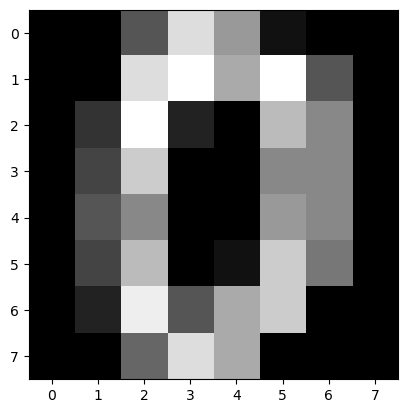

In [4]:
import matplotlib.pyplot as plt
plt.gray() 
plt.imshow(digits.images[0]) 
plt.show() 

# from before, use the import matplot to display the image variation from digits dataset

<h4>Create the feature matrix and target vector</h4>

In [5]:
# Create feature matrix- This is all of the images in the dataaset
X = digits.data
# Create target vector
y = digits.target
# View the first images's feature values as a flattened vector
X[0]


# Set the digits datasets to X and y variables, flatten the images.

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

The observation’s feature values are presented as a vector. However, by using the images method we can load the the same feature values as
a matrix and then visualize the actual handwritten character:

In [6]:
# View the first image's feature values as an image array (matrix)
digits.images[0]


# display the images as an array matrix

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [7]:
# The digits dataset
print("The digits are NumPy arrays as can be seen here: {}".format(type(digits.images[0])))

# show the class

The digits are NumPy arrays as can be seen here: <class 'numpy.ndarray'>


In [8]:
print('The array for an arbitrary digit is: \n\n{}'.format(digits.images[0]))

# array

The array for an arbitrary digit is: 

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


In [9]:
print('The target vector consists of digits from 0 to 9. The first 20 are printed below {}'
 .format(digits.target[:20]))

#printing the first 20 digits from the dataset

The target vector consists of digits from 0 to 9. The first 20 are printed below [0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9]


<h4>Normalize the data for better fitting and convergence</h4>

In [10]:
#before normalization
print(f'before normalization: X_min={X.min()}, X_max={X.max()}')

# The min and max for the pixel intensity

before normalization: X_min=0.0, X_max=16.0


In [11]:
#Normalize the dataset. We should really be using something like MinMaxScaler here!
X = X/16.0

# divide by the largest value to change the min and max to be inbetween 0 and 1.

In [12]:
#after normalization
print(f'after normalization: X_min={X.min()}, X_max={X.max()}')

# The new min and max after normalizing it.

after normalization: X_min=0.0, X_max=1.0


<h4>Model Training: Training and Testing Data</h4>
<h4>Test/train splits of data</h4>
Scikit learn contains a function called the train_test_split function that will randomly shuffle the dataset and then splits it into two datasets: a
training set used to build the model and a test set to assess and evaluate how well the model works on unseen data (also called out-ofsample data). The train_test_split function by default does a 75%/25% train/test split but the split can be modified by tuning the parameters of
the function as indicated below in the code.


In [13]:
from sklearn.model_selection import train_test_split
import numpy as np
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Splitting the training and testing sets

<h4>Print a selection of training images and their labels<h4>
    

In [14]:
def plot_example(X, y):
 """Plot the first 5 images and their labels in a row."""
 for i, (img, y) in enumerate(zip(X[:5].reshape(5, 8, 8), y[:5])):
     plt.subplot(151 + i)
     plt.imshow(img)
     plt.xticks([])
     plt.yticks([])
     plt.title(y)

# Plotting the first 5 images from the split datasets

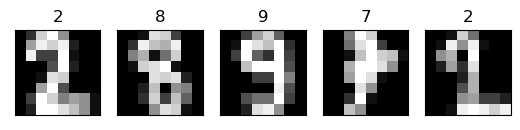

In [15]:
plot_example(X_train, y_train)

<h4>Is the Training Dataset Balanced?</h4>
Let's plot a histogram of the training dastset labels class labels to make sure we have a balanaced dataset, i.e.we want to figure out how often
each number is represented in the training dataset This is important when we are trying to eliminate algorithmic bias in our machine learning
models.


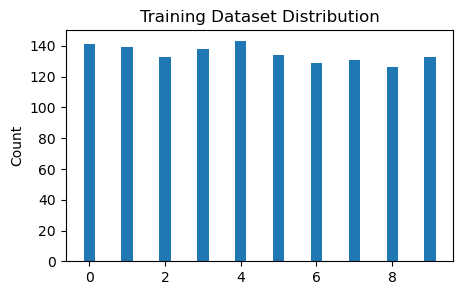

In [16]:
# TO-DO: Plot the barchart or histogram to show that the dataset is balanced (or not)
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.bar(np.unique(y_train),np.bincount(y_train),width=.3 )
plt.ylabel("Count")
plt.title("Training Dataset Distribution")

plt.show()

# Histogram

We can visually inspect to see if the dataset is balanced. We see that the number of examples for each number to detect is not evenly
distributed. There are more of some numbers than others in the training dataset.

<h4>Shape of our dataset</h4>
We also want to look at the shape of the data and the proportions of the training set (after the split) that will be used for training the classifier
on each unique class label (digit). We use Numpy(see below) to examinie the unique clss label and the bins (actually the bin count) that the
training set has been allocated to.

In [17]:
print('X_train Shape of the data : {}'.format(X_train.shape))
print('y_train Shape of the data : {}'.format(y_train.shape))

# Shape of the data

X_train Shape of the data : (1347, 64)
y_train Shape of the data : (1347,)


In [18]:
print('X_test Shape of the data : {}'.format(X_test.shape))
print('y_test Shape of the data : {}'.format(y_test.shape))

# Shape of the data

X_test Shape of the data : (450, 64)
y_test Shape of the data : (450,)


In [19]:
print('Class labels:', np.unique(y_train))
print('Class proportions:', np.bincount(y_train))

# print the labels and proportions

Class labels: [0 1 2 3 4 5 6 7 8 9]
Class proportions: [141 139 133 138 143 134 129 131 126 133]


<h4>Building the Multilayer Perceptron Model</h4>
We will use the MLPClassifier. The MLPClassifier trains iteratively since at each time step the partial derivatives of the loss function with
respect to the model parameters are computed to update the parameters.
It can also have a regularization term added to the loss function that shrinks model parameters to prevent overfitting.
This implementation works with data represented as dense numpy arrays or sparse scipy arrays of floating point values.

<b>The Model using a Multilayer Perceptron Classifier</b>

Build the model with 3 hidden layers as follows:

<li>hidden layer = 256 neurons</li>
<li>hidden layer = 128 neurons</li>
<li>hidden layer = 32 neurons</li>

also, use these parameters

<li>solver ='adam'</li>
<li>learning_rate_init= 0.001</li>
<li>tol=1e-3</li>
<li>max_iter= 500</li>

You can use the default values for the rest of the parameters

In [20]:
#TO-DO Name the model as below
mlp_digits_model = MLPClassifier(solver='adam' ,hidden_layer_sizes=(256, 128, 32), learning_rate_init= 0.001,
                   random_state=1, max_iter=500, verbose=True, tol=1.0e-3)

# The mlp_digits_model set to a variable

<b>Train (fit) the Model</b>

In [21]:
mlp_digits_model.fit(X_train, y_train)

# The trainingsets fit to the model.

Iteration 1, loss = 2.21201285
Iteration 2, loss = 1.91997939
Iteration 3, loss = 1.59956906
Iteration 4, loss = 1.25220491
Iteration 5, loss = 0.93383059
Iteration 6, loss = 0.67201470
Iteration 7, loss = 0.46859656
Iteration 8, loss = 0.33647097
Iteration 9, loss = 0.26148813
Iteration 10, loss = 0.21236294
Iteration 11, loss = 0.17445019
Iteration 12, loss = 0.14615723
Iteration 13, loss = 0.13275401
Iteration 14, loss = 0.11837077
Iteration 15, loss = 0.10279143
Iteration 16, loss = 0.09009844
Iteration 17, loss = 0.08173481
Iteration 18, loss = 0.07373088
Iteration 19, loss = 0.06741745
Iteration 20, loss = 0.06523791
Iteration 21, loss = 0.05963855
Iteration 22, loss = 0.05138053
Iteration 23, loss = 0.04685198
Iteration 24, loss = 0.04396454
Iteration 25, loss = 0.03962136
Iteration 26, loss = 0.03800353
Iteration 27, loss = 0.03370493
Iteration 28, loss = 0.03074843
Iteration 29, loss = 0.02816596
Iteration 30, loss = 0.02627824
Iteration 31, loss = 0.02443557
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(256, 128, 32), max_iter=500, random_state=1,
              tol=0.001, verbose=True)

<b>Plot the loss during training</b>

A loss function, also known as a cost function, takes into account the probabilities or uncertainty of a prediction based on how much the
prediction varies from the true value. This gives us a more nuanced view into how well the model is performing.
Unlike accuracy, loss is not a percentage — it is a summation of the errors made for each sample in training or validation sets. Loss is often
used in the training process to find the "best" parameter values for the model (e.g. weights in neural network). During the training process the
goal is to minimize this value.

In [22]:
loss_values = mlp_digits_model.loss_curve_
# Add the loss curve model

Text(0, 0.5, 'loss')

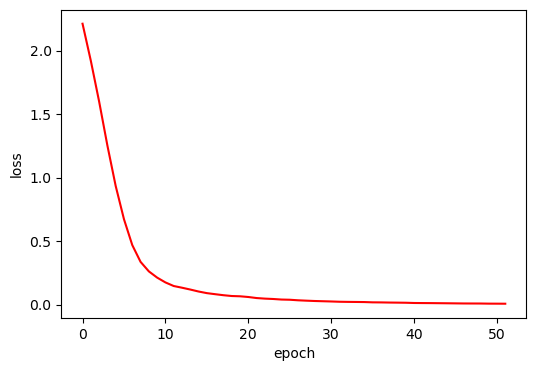

In [23]:
# TO-DO Plot the loss_values (Label each axis, put a legend and put a title on plot.)
fig=plt.figure(figsize=(6,4))
plt.plot(loss_values, color="red", label = 'training loss')
plt.xlabel('epoch')
plt.ylabel('loss')

# plotting the loss curve

<b>Let's Evaluate the MLPClassifier Model</b>

We do this by using the test set that we created earlier. Note that this data was not used to build (train) the model, but we do know what the
digits are (correct class labels) for each image in the test set. Thus, we can make a prediction for each image in the test data and compare it to
its known class label (known digit). We can measure how well the model works by computing the model's accuracy, which is the fraction of
images for which the right digit was predicted.

Let's Proceed: We will feed the test set of data into the classifier's predictor method and have it predict what the output digit is for each input
image of the test set. The number of responses we get will be equal to the number of input images in the test set.

<b>Model Performance - Predictions</b>

In [24]:
# Now predict the value of the digit on the test set data:
y_pred = mlp_digits_model.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))

# Predicting the values of the digits in the test datasets.

Test set predictions:
 [2 8 2 6 6 7 1 9 8 5 2 8 6 6 6 6 1 0 5 8 8 7 8 4 7 5 4 9 2 9 4 7 6 8 9 4 3
 1 0 1 8 6 7 7 1 0 7 6 2 1 9 6 7 9 0 0 5 1 6 3 0 2 3 4 1 9 2 6 9 1 8 3 5 1
 2 8 2 2 9 7 2 3 6 0 5 3 7 5 1 2 9 9 3 1 7 7 4 8 5 8 5 5 2 5 9 0 7 1 4 7 3
 4 8 9 7 9 8 2 1 5 2 5 5 4 1 7 0 6 1 5 5 9 9 5 9 9 5 7 5 6 2 8 6 9 6 1 5 1
 5 9 9 1 5 3 6 1 8 9 8 7 6 7 6 5 6 0 8 8 9 8 6 1 0 4 1 6 3 8 6 7 4 9 6 3 0
 3 3 3 0 7 7 5 7 8 0 7 1 9 6 4 5 0 1 4 6 4 3 3 0 9 5 9 2 1 4 2 1 6 8 9 2 4
 9 3 7 6 2 3 3 1 6 9 3 6 3 2 2 0 7 6 1 1 9 7 2 7 8 5 5 7 5 2 3 7 2 7 5 5 7
 0 9 1 6 5 9 7 4 3 8 0 3 6 4 6 3 2 6 8 8 8 4 6 7 5 2 4 5 3 2 4 6 9 4 5 4 3
 4 6 2 9 0 1 7 2 0 9 6 0 4 2 0 7 9 8 5 7 8 2 8 4 3 7 2 6 9 1 5 1 0 8 2 8 9
 5 6 2 2 7 2 1 5 1 6 4 5 0 9 4 1 1 7 0 8 9 0 5 4 3 8 8 6 5 3 4 4 4 8 8 7 0
 9 6 3 5 2 3 0 8 2 3 1 3 3 0 0 4 6 0 7 7 6 2 0 4 4 2 3 7 1 9 8 6 8 5 6 2 2
 3 1 7 7 8 0 3 3 2 1 5 5 9 1 3 7 0 0 7 0 4 5 9 3 3 4 3 1 8 9 8 3 6 2 1 6 2
 1 7 5 5 1 9]


<b>Model Performance - Accuracy</b>

Let's use NumPy to compute the performance accuracy

In [25]:
print("Test set score using NumPy: {0:0.2f}".format(np.mean(y_pred==y_test)))

# Using Numpy to display the accuracy

Test set score using NumPy: 0.98


We can also use the score method of the mlp object, which will compute the test set score accuracy for us:


In [26]:
print("Test set score (accuracy on test set): {0:0.2f}".format(mlp_digits_model.score(X_test,y_test)))


# Displaying the test set scores

Test set score (accuracy on test set): 0.98


A mean score of approximately 0.97 is really excellent. An accuracy of about 97% for a network with only three hidden layers is not too bad.
Let's take a look at some predictions that the model got wrong:

<b>Model Performance-Errors</b>

In [27]:
error_mask = y_pred != y_test

# Testing

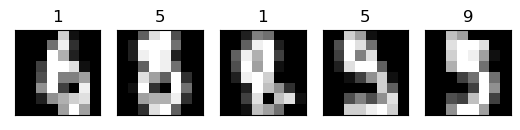

In [28]:
plot_example(X_test[error_mask], y_pred[error_mask])

# Plot the test

<b>Classification Report and Confusion Matrix</b>

Two further metrics are the classifcation report and the confusion matrix that shows the errors that the classifier made during training.

<b>Classifcation Report</b>


In [29]:
from sklearn import metrics
print ("Classification Report:")
print (metrics.classification_report(y_test, y_pred))

# Classification report

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.91      0.98      0.94        43
           2       0.96      1.00      0.98        44
           3       1.00      0.98      0.99        45
           4       1.00      0.97      0.99        38
           5       0.96      0.98      0.97        48
           6       1.00      0.98      0.99        52
           7       0.98      1.00      0.99        48
           8       0.98      0.90      0.93        48
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



<b>Confusion Matrix</b>

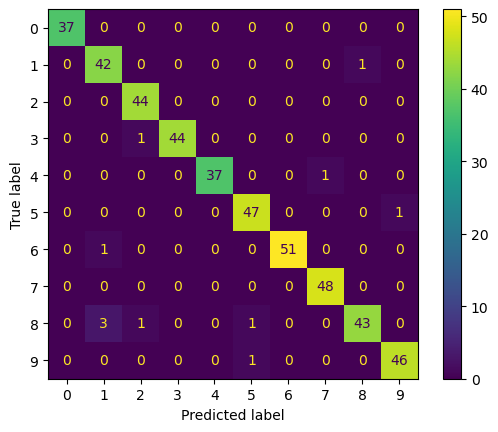

In [30]:
#TO-DO: print a pretty confusion matrix (see previous notebooks)

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred, labels=mlp_digits_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=mlp_digits_model.classes_)
disp.plot()

plt.show()

# Confusion matrix for digits

<b>Let's plot some of the images and the predicitions</b>

<li>NOTE: BELOW I had to TEMPORARILY reshape the X_test data back into 8 x 8 image arrays</li>
<li>This is done so that matplotlib could display them using imshow()**</li>

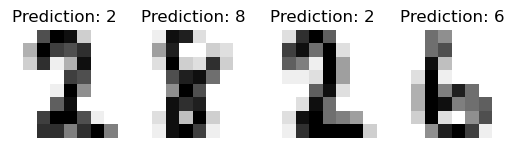

In [31]:
images_and_predictions = list(zip(X_test.reshape(len(X_test),8,8), y_pred))
for index, (image, prediction) in enumerate(images_and_predictions[:4]):
 plt.subplot(2, 4, index + 1 )
 plt.axis('off')
 plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
 plt.title('Prediction: %i' % prediction)
plt.show()

# Displaying the predictions

<center>
    <h2 style = "color:red">Exercises<h2>
        </center>
    <h3 style = "color:green">Answer the questions below in your notebook. Submit ONLY your completed Jupyter Notebook. Do NOT zip it with any other files or folders and do not put anyimages in it in the heading or elsewhere.</h3>
        <h3>Exercise 1 (5 points)</h3>
        <li>Based on the confusion matrix, which digit was hardest for the model to classify? Justify your answer!.</li>

From the confusion mstrix, the 8th digit was hardest for the model to classify from the dataset. The confusion matrix showed that the 8th digit had the most misclassifications.

<h3>Exercise 2 (15 points)</h3>

<li>In a cell below, train the model using the 'sgd' optimizer (scikit learn calls it a solver). Call the model sgd_mlp_digits_model . Does
the accuracy improve? Comment (one line!) as to what you think is contributing to the change in performance of the model.
<li>Adjust the tolerance (set it to 1e-4) and set verbose =True (WOW on the output!). Comment on the model's performance accuracy
<li>OK, set verbose back to False . You should have gotten a convergence warning. Adjust the max_iter to eliminate the warning. Accuracy?
<li>Change the learning rate to 0.01 and run the model with sgd as the optimizer. How does it perform? How many iterations before it
converged.?

In [32]:
#Your code here
mlp = MLPClassifier(solver='sgd' ,hidden_layer_sizes=(256, 128, 32), learning_rate_init= 0.01,
                   random_state=1, max_iter=500, verbose=True , tol=1.0e-4)
mlp_digits_model = mlp
mlp_digits_model.fit(X_train, y_train)

Iteration 1, loss = 2.31149877
Iteration 2, loss = 2.22210021
Iteration 3, loss = 2.12748988
Iteration 4, loss = 2.00948648
Iteration 5, loss = 1.87698215
Iteration 6, loss = 1.72230456
Iteration 7, loss = 1.54367858
Iteration 8, loss = 1.34201338
Iteration 9, loss = 1.12836349
Iteration 10, loss = 0.92219776
Iteration 11, loss = 0.74631691
Iteration 12, loss = 0.61311242
Iteration 13, loss = 0.51668589
Iteration 14, loss = 0.44163909
Iteration 15, loss = 0.38303870
Iteration 16, loss = 0.34227005
Iteration 17, loss = 0.30612895
Iteration 18, loss = 0.27801861
Iteration 19, loss = 0.25318985
Iteration 20, loss = 0.23774224
Iteration 21, loss = 0.22025708
Iteration 22, loss = 0.20339923
Iteration 23, loss = 0.19117521
Iteration 24, loss = 0.18127396
Iteration 25, loss = 0.17120721
Iteration 26, loss = 0.16390848
Iteration 27, loss = 0.15298432
Iteration 28, loss = 0.14666797
Iteration 29, loss = 0.14039261
Iteration 30, loss = 0.13327569
Iteration 31, loss = 0.12926081
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(256, 128, 32), learning_rate_init=0.01,
              max_iter=500, random_state=1, solver='sgd', verbose=True)

The printed output was more accurate.

<h3>Exercise 3 (5 points)</h3>
<li>Feed the model a single image from the test set to classify and have the model return the class membership probabilities and print them
out for this single image classification. From this probability distribution, what is the most likely digit represented by the image fed it?
<li>Print out the associated test label to verify.
<li>Display the image to see if it agrees with the prediction. Note you may have to reshape the image to 8 x 8 before you try and display it!

The predicted digit is :  2
The true digit is 2
The corresponding predicted image is:


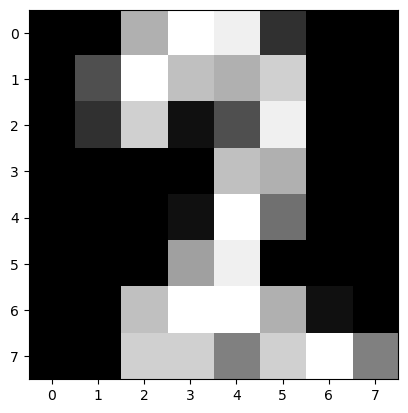

In [33]:
prediction = y_pred
index=0
prediction[index]
print('The predicted digit is : ',prediction[index])
print('The true digit is {}'.format(y_test[index]))
print('The corresponding predicted image is:')
plt.imshow(X_test[index].reshape(8, 8))
plt.show()